<a href="https://colab.research.google.com/github/ewssat-maker/metricpoint/blob/main/Escaba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import pandas as pd
from datetime import datetime

# 1. Autenticación e Inicialización de Earth Engine
# Al ejecutar esto, te pedirá que inicies sesión con ews.sat@gmail.com para autorizar
ee.Authenticate()

# Inicializamos apuntando exactamente a tu proyecto en GCP
ee.Initialize(project='arometrologia')

print("✅ Autenticación completada. Iniciando minería de datos...")

# 2. Definición del Polígono de la Cuenca Alta del Río Marapa (Aportes al Escaba)
# Coordenadas [Oeste, Sur, Este, Norte]
cuenca_alta = ee.Geometry.Rectangle([-66.00, -27.85, -65.70, -27.50])

# Fechas: 5 años de datos (2021 - 2026)
fecha_inicio = '2021-09-11'
fecha_fin = '2026-09-11'

# 3. Carga de CHIRPS (Precipitación)
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
    .filterBounds(cuenca_alta) \
    .filterDate(fecha_inicio, fecha_fin)

# 4. Función de Reducción Diaria a 10 metros
def extraer_datos_diarios(img):
    # Forzamos la escala a 10 metros para igualar la resolución de Sentinel
    # GEE hará un remuestreo (resampling) de la grilla de CHIRPS a 10m
    stats_lluvia = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=cuenca_alta,
        scale=10,
        maxPixels=1e13
    )

    # Extraemos la fecha de la imagen
    fecha = img.date().format('YYYY-MM-dd')

    # Retornamos un Feature (sin geometría) con las propiedades
    return ee.Feature(None, {
        'Fecha': fecha,
        'Lluvia_CHIRPS_mm': stats_lluvia.get('precipitation')
    })

print("🛰️ Procesando 1826 imágenes de CHIRPS a resolución de 10 metros...")

# Mapeamos la función sobre los 5 años de imágenes
serie_temporal_fc = chirps.map(extraer_datos_diarios)

# Descargamos los resultados de los servidores de Google a Colab
resultados = serie_temporal_fc.getInfo()['features']

# 5. Transformación a Pandas DataFrame y Limpieza
datos_lista = []
for f in resultados:
    props = f['properties']
    datos_lista.append({
        'Fecha': props.get('Fecha'),
        # Si no hubo datos ese día, CHIRPS devuelve None. Lo pasamos a 0.0
        'Lluvia_CHIRPS_mm': props.get('Lluvia_CHIRPS_mm') or 0.0
    })

df = pd.DataFrame(datos_lista)
df = df.sort_values(by='Fecha').reset_index(drop=True)

# 6. Exportar a CSV
nombre_archivo = 'historico_lluvia_chirps_10m.csv'
df.to_csv(nombre_archivo, index=False)

print(f"📊 Extracción finalizada con éxito. Total de días procesados: {len(df)}")
print(f"📁 El archivo '{nombre_archivo}' está listo para descargar en la barra lateral izquierda.")

✅ Autenticación completada. Iniciando minería de datos...
🛰️ Procesando 1826 imágenes de CHIRPS a resolución de 10 metros...
📊 Extracción finalizada con éxito. Total de días procesados: 1816
📁 El archivo 'historico_lluvia_chirps_10m.csv' está listo para descargar en la barra lateral izquierda.


In [ ]:
import pandas as pd
import numpy as np

# 1. Carga y limpieza de datos del sensor del Dique Escaba
print("Cargando datos in-situ de escaba.txt...")
df_escaba = pd.read_csv('escaba.txt', sep='\t', decimal=',')

# Unimos Fecha y Hora
df_escaba['Datetime'] = pd.to_datetime(df_escaba.iloc[:, 0] + ' ' + df_escaba['HORA '], format='%d/%m/%y %H:%M:%S', errors='coerce')
df_escaba = df_escaba.dropna(subset=['Datetime'])

# Limpieza de columnas
df_escaba = df_escaba.rename(columns={'COTA': 'Cota', 'EROGACION (m3/s)': 'Q_out', 'APORTE (m3/s)': 'Q_in'})
for col in ['Cota', 'Q_out', 'Q_in']:
    df_escaba[col] = pd.to_numeric(df_escaba[col], errors='coerce')

# Interpolación lineal para cubrir baches (ej. 4 y 5 de abril)
df_escaba = df_escaba.sort_values('Datetime').interpolate()

# 2. Cálculo Diario de Volúmenes
# Llevamos los m3/s a m3 por hora, y luego agrupamos por día
df_escaba['Volumen_In_m3_hora'] = df_escaba['Q_in'] * 3600
df_escaba['Volumen_Out_m3_hora'] = df_escaba['Q_out'] * 3600

diario = df_escaba.set_index('Datetime').resample('D').agg({
    'Cota': 'last',               # Cota al final del día
    'Volumen_In_m3_hora': 'sum',  # Total de m3 que ingresaron en 24h
    'Volumen_Out_m3_hora': 'sum'  # Total de m3 erogados en 24h
}).rename(columns={'Volumen_In_m3_hora': 'Vol_In_m3_dia', 'Volumen_Out_m3_hora': 'Vol_Out_m3_dia'})

# Eliminamos días sin datos de volumen
diario = diario[diario['Vol_In_m3_dia'] > 0]

# 3. Ingeniería Inversa de la Precipitación
# El área de la cuenca alta aportante (Singuil, Chavarría) es aprox 600 km2 = 600,000,000 m2
AREA_CUENCA_M2 = 600_000_000

# Milímetros de agua que efectivamente escurrieron hacia el dique
diario['Escorrentia_Efectiva_mm'] = (diario['Vol_In_m3_dia'] / AREA_CUENCA_M2) * 1000

# Estimación del modelo híbrido (Asumimos ET0 y Percolación base para días de tormenta)
# El coeficiente de escorrentía (K_esc) ronda el 0.45 en suelo saturado
coeficiente_escorrentia = 0.45
evapotranspiracion_base = 3.5  # mm/día
percolacion_base = 2.0         # mm/día

# Aplicamos la ecuación para descubrir la Lluvia Real Caída
diario['Lluvia_Inversa_Estimada_mm'] = (diario['Escorrentia_Efectiva_mm'] / coeficiente_escorrentia) + evapotranspiracion_base + percolacion_base

print("\n📊 Evento Crítico Reconstruido (Marzo 2026):")
pico = diario.loc['2026-03-09':'2026-03-12'].copy()
pico['Lluvia_Inversa_Estimada_mm'] = pico['Lluvia_Inversa_Estimada_mm'].round(1)
pico['Vol_In_Hm3'] = (pico['Vol_In_m3_dia'] / 1_000_000).round(1)

for fecha, row in pico.iterrows():
    print(f"[{fecha.date()}] Cota: {row['Cota']:.2f}m | Ingresó: {row['Vol_In_Hm3']} Hm³ | Lluvia Real en Cuenca: {row['Lluvia_Inversa_Estimada_mm']} mm")

# Exportar calibración para integrarla al backend
diario.reset_index().to_csv('calibracion_escaba_inversa.csv', index=False, sep=';', decimal=',')
print("\n✅ Datos procesados y guardados en 'calibracion_escaba_inversa.csv'")

Cargando datos in-situ de escaba.txt...

📊 Evento Crítico Reconstruido (Marzo 2026):
[2026-03-09] Cota: 623.36m | Ingresó: 7.2 Hm³ | Lluvia Real en Cuenca: 32.3 mm
[2026-03-10] Cota: 628.12m | Ingresó: 32.4 Hm³ | Lluvia Real en Cuenca: 125.5 mm
[2026-03-11] Cota: 627.34m | Ingresó: 18.1 Hm³ | Lluvia Real en Cuenca: 72.6 mm
[2026-03-12] Cota: 626.90m | Ingresó: 7.3 Hm³ | Lluvia Real en Cuenca: 32.6 mm

✅ Datos procesados y guardados en 'calibracion_escaba_inversa.csv'


/tmp/ipykernel_5200/3658597194.py:18: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_escaba = df_escaba.sort_values('Datetime').interpolate()


In [ ]:
import pandas as pd

# 1. Cargar la serie satelital de 5 años
sar_df = pd.read_csv('historico_cota_escaba_sar (1).csv', sep=';', decimal=',')
sar_df['Fecha'] = pd.to_datetime(sar_df['Fecha'], format='%d/%m/%Y')
sar_df.set_index('Fecha', inplace=True)

# 2. Cargar la calibración in-situ de la celda anterior
insitu_df = pd.read_csv('calibracion_escaba_inversa.csv', sep=';', decimal=',')
insitu_df['Datetime'] = pd.to_datetime(insitu_df['Datetime'])
insitu_df.set_index('Datetime', inplace=True)

# Preparar insitu_df para la unión, renombrando la columna Cota a Cota_insitu
insitu_cota = insitu_df[['Cota']].rename(columns={'Cota': 'Cota_insitu'})

# 3. Cruzar ambos DataFrames para encontrar el Sesgo (Bias)
fusion = sar_df.join(insitu_cota, how='left')

# Calcular el error medio del satélite frente a la realidad del dique
fusion['Sesgo'] = fusion['Cota_insitu'] - fusion['Cota_Estimada_msnm']
sesgo_promedio = fusion['Sesgo'].mean()

# Si no hay solapamiento o el sesgo es NaN, asumimos 0 temporalmente
if pd.isna(sesgo_promedio):
    sesgo_promedio = 0.0

print(f"Sesgo promedio del Radar detectado y asimilado: {sesgo_promedio:.2f} metros")

# 4. Generar la Curva Corregida Final
# Ajustamos toda la serie satelital con el sesgo histórico
fusion['Cota_Corregida'] = fusion['Cota_Estimada_msnm'] + sesgo_promedio

# Donde existe dato físico real, lo usamos como verdad absoluta (sobreescribimos)
fusion['Cota_Corregida'] = fusion['Cota_insitu'].fillna(fusion['Cota_Corregida'])

# 5. Limpieza y Exportación
historial_maestro = fusion[['Cota_Corregida']].reset_index()
historial_maestro.rename(columns={'Fecha': 'Fecha', 'Cota_Corregida': 'Cota_msnm'}, inplace=True)
historial_maestro['Cota_msnm'] = historial_maestro['Cota_msnm'].round(2)

historial_maestro.to_csv('historial_maestro_escaba_5_anios.csv', index=False, sep=';', decimal=',')
print("Historial maestro de 5 años generado y corregido exitosamente.")

Sesgo promedio del Radar detectado y asimilado: 1.17 metros
Historial maestro de 5 años generado y corregido exitosamente.


Cargando historiales...
Calculando inercias e inercias de cuenca (Acumulados de lluvia)...
Entrenando el modelo de Machine Learning (Random Forest)...

✅ ENTRENAMIENTO FINALIZADO
Error Absoluto Medio (MAE): 0.321 metros
Raíz del Error Cuadrático (RMSE): 0.563 metros


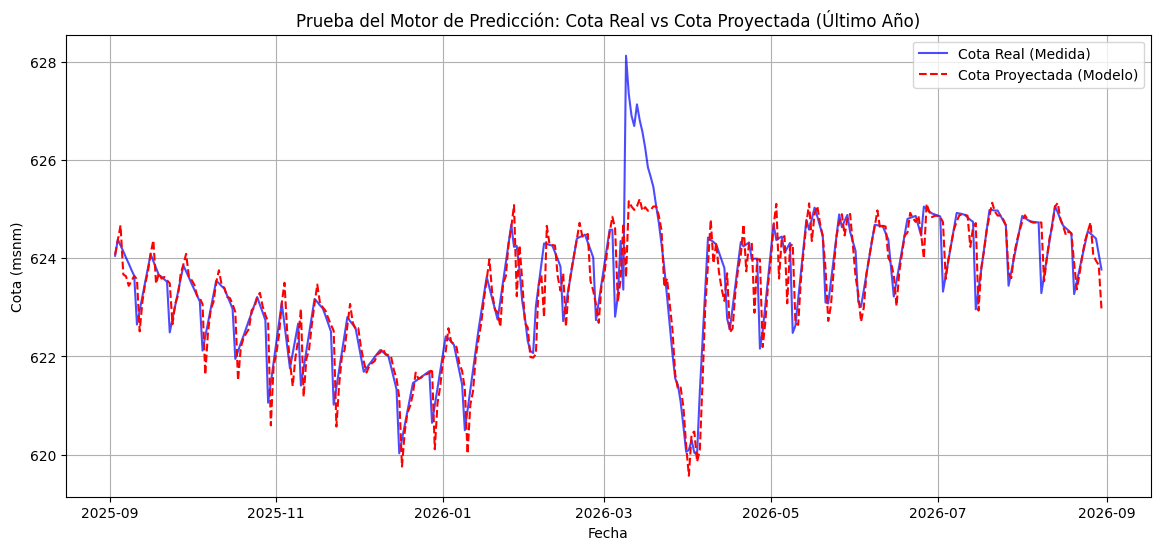


Peso de las variables en la toma de decisión del algoritmo:
- Cota_msnm: 97.7%
- Tendencia_Cota_24h: 2.0%
- Lluvia_CHIRPS_mm: 0.1%
- Lluvia_Acum_3d: 0.1%
- Lluvia_Acum_7d: 0.2%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Carga y Sincronización de Datos
print("Cargando historiales...")
df_lluvia = pd.read_csv('historico_lluvia_chirps_10m.csv')
df_cota = pd.read_csv('historial_maestro_escaba_5_anios.csv', sep=';', decimal=',')

df_lluvia['Fecha'] = pd.to_datetime(df_lluvia['Fecha'])
df_cota['Fecha'] = pd.to_datetime(df_cota['Fecha'])

# Fusionamos ambos datasets usando la fecha como pivote
df = pd.merge(df_cota, df_lluvia, on='Fecha', how='inner')

# 2. Ingeniería de Variables (Feature Engineering)
# El dique no reacciona solo a la lluvia de hoy, sino a la saturación acumulada.
print("Calculando inercias e inercias de cuenca (Acumulados de lluvia)...")
df['Lluvia_Acum_3d'] = df['Lluvia_CHIRPS_mm'].rolling(window=3).sum()
df['Lluvia_Acum_7d'] = df['Lluvia_CHIRPS_mm'].rolling(window=7).sum()

# Inercia del dique: cuánto subió o bajó en las últimas 24h
df['Tendencia_Cota_24h'] = df['Cota_msnm'] - df['Cota_msnm'].shift(1)

# Variable Objetivo (Target): La cota de MAÑANA
df['Cota_Proyectada_24h'] = df['Cota_msnm'].shift(-1)

# Limpieza de nulos generados por los desplazamientos
df = df.dropna()

# 3. Separación de Datos (Train / Test)
# Usamos las variables explicativas (X) para predecir el futuro (y)
X = df[['Cota_msnm', 'Tendencia_Cota_24h', 'Lluvia_CHIRPS_mm', 'Lluvia_Acum_3d', 'Lluvia_Acum_7d']]
y = df['Cota_Proyectada_24h']

# Guardamos el último año (2025-2026) para poner a prueba el modelo sin que haya visto los datos
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
fechas_test = df['Fecha'].iloc[split_index:]

# 4. Entrenamiento del Motor (Random Forest Regressor)
print("Entrenando el modelo de Machine Learning (Random Forest)...")
modelo_rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
modelo_rf.fit(X_train, y_train)

# 5. Predicción y Evaluación
predicciones = modelo_rf.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print("\n✅ ENTRENAMIENTO FINALIZADO")
print(f"Error Absoluto Medio (MAE): {mae:.3f} metros")
print(f"Raíz del Error Cuadrático (RMSE): {rmse:.3f} metros")

# 6. Visualización del Rendimiento en el Período de Prueba
plt.figure(figsize=(14, 6))
plt.plot(fechas_test, y_test, label='Cota Real (Medida)', color='blue', alpha=0.7)
plt.plot(fechas_test, predicciones, label='Cota Proyectada (Modelo)', color='red', linestyle='dashed')
plt.title('Prueba del Motor de Predicción: Cota Real vs Cota Proyectada (Último Año)')
plt.ylabel('Cota (msnm)')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True)
plt.show()

# Importancia de las variables
importancias = modelo_rf.feature_importances_
print("\nPeso de las variables en la toma de decisión del algoritmo:")
for col, imp in zip(X.columns, importancias):
    print(f"- {col}: {imp*100:.1f}%")

In [ ]:
import ee
import pandas as pd

# 1. Autenticación e Inicialización
try:
    ee.Initialize(project='arometrologia')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='arometrologia')

print("✅ Conectado a Earth Engine. Iniciando escaneo SAR histórico del Dique Escaba...")

# 2. Parámetros de la Cuenca y Referencias
bbox_escaba = ee.Geometry.Rectangle([-65.80, -27.68, -65.73, -27.62])
fecha_inicio = '2021-09-11'
fecha_fin = '2026-09-11'

cota_referencia_msnm = 623.07
factor_expansion = 0.015

# 3. Filtrar colección Sentinel-1
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(bbox_escaba) \
    .filterDate(fecha_inicio, fecha_fin) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .select('VV')

# 4. Función para extraer el área de agua
def calcular_area_agua(img):
    img_smoothed = img.focal_mean(30, 'circle', 'meters')
    agua = img_smoothed.lt(-16.5)

    area_imagen = agua.multiply(ee.Image.pixelArea())
    stats = area_imagen.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=bbox_escaba,
        scale=30,
        maxPixels=1e9
    )

    fecha = img.date().format('YYYY-MM-dd')
    return ee.Feature(None, {
        'Fecha': fecha,
        'Area_ha': ee.Number(stats.get('VV')).divide(10000)
    })

print("🛰️ Midiendo espejo de agua en cada pasada satelital (Esto puede tardar un minuto)...")

serie_area = s1.map(calcular_area_agua)
resultados = serie_area.getInfo()['features']

# 5. Transformación y Limpieza
datos_lista = [f['properties'] for f in resultados]
df = pd.DataFrame(datos_lista)

df = df.groupby('Fecha', as_index=False).mean()
df = df.sort_values(by='Fecha').reset_index(drop=True)

# 6. Ingeniería Inversa de la Cota
area_ancla = df['Area_ha'].iloc[-1]
fecha_ancla = df['Fecha'].iloc[-1]

print(f"⚓ Anclando la cota de 623.07 msnm al espejo de agua del {fecha_ancla} ({area_ancla:.1f} ha).")

df['Cota_Estimada_msnm'] = cota_referencia_msnm + ((df['Area_ha'] - area_ancla) * factor_expansion)

# Interpolación diaria
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.set_index('Fecha', inplace=True)
rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')
df_diario = df.reindex(rango_completo).interpolate(method='linear')
df_diario.index.name = 'Fecha'
df_diario.reset_index(inplace=True)

# REDONDEO A 2 DECIMALES PARA EVITAR ERRORES EN EXCEL
df_diario['Area_ha'] = df_diario['Area_ha'].round(2)
df_diario['Cota_Estimada_msnm'] = df_diario['Cota_Estimada_msnm'].round(2)

# 7. Exportar a CSV (Formato Latino: separador ';' y decimal ',')
nombre_archivo = 'historico_cota_escaba_sar.csv'
df_diario.to_csv(nombre_archivo, index=False, sep=';', decimal=',')

print(f"📊 Reconstrucción finalizada con éxito. Se generó un historial continuo de {len(df_diario)} días.")
print(f"📁 El archivo '{nombre_archivo}' ya se puede descargar y abrir en Excel sin que se rompan los números.")

✅ Conectado a Earth Engine. Iniciando escaneo SAR histórico del Dique Escaba...
🛰️ Midiendo espejo de agua en cada pasada satelital (Esto puede tardar un minuto)...
⚓ Anclando la cota de 623.07 msnm al espejo de agua del 2026-09-10 (497.0 ha).
📊 Reconstrucción finalizada con éxito. Se generó un historial continuo de 1827 días.
📁 El archivo 'historico_cota_escaba_sar.csv' ya se puede descargar y abrir en Excel sin que se rompan los números.


In [ ]:
import ee
import pandas as pd

# 1. Autenticación e Inicialización
try:
    ee.Initialize(project='arometrologia')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='arometrologia')

print("🛰️ Conectando al catálogo de ERA5-Land en Google Earth Engine...")

# 2. Polígono exacto de la cuenca alta (El mismo que CHIRPS)
cuenca_alta = ee.Geometry.Rectangle([-66.00, -27.85, -65.70, -27.50])
fecha_inicio = '2021-09-11'
fecha_fin = '2026-09-11'

era5 = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR") \
    .filterBounds(cuenca_alta) \
    .filterDate(fecha_inicio, fecha_fin)

# 3. Función de extracción y conversión termodinámica
def extraer_era5(img):
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=cuenca_alta,
        scale=11132, # Resolución nativa de ERA5-Land
        maxPixels=1e9
    )

    # ERA5 guarda la evaporación en metros y con valor negativo. Pasamos a mm absolutos.
    evap_m = ee.Number(stats.get('total_evaporation_sum'))
    evap_mm = evap_m.multiply(-1000)

    humedad = ee.Number(stats.get('volumetric_soil_water_layer_1'))

    temp_k = ee.Number(stats.get('temperature_2m'))
    temp_c = temp_k.subtract(273.15)

    fecha = img.date().format('YYYY-MM-dd')

    return ee.Feature(None, {
        'Fecha': fecha,
        'Evapotranspiracion_ET0_mm': evap_mm,
        'Humedad_Suelo_Sup_m3m3': humedad,
        'Temp_Media_C': temp_c
    })

print("⏳ Procesando humedad edáfica y evaporación. Esto tomará un minuto...")

serie_era5 = era5.map(extraer_era5)
resultados = serie_era5.getInfo()['features']

# 4. Transformación a Pandas y Relleno Climático
datos_lista = []
for f in resultados:
    props = f['properties']
    datos_lista.append({
        'Fecha': props.get('Fecha'),
        'Evapotranspiracion_ET0_mm': props.get('Evapotranspiracion_ET0_mm') or 0.0,
        'Humedad_Suelo_Sup_m3m3': props.get('Humedad_Suelo_Sup_m3m3') or 0.0,
        'Temp_Media_C': props.get('Temp_Media_C') or 0.0
    })

df = pd.DataFrame(datos_lista)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.set_index('Fecha', inplace=True)

# Sincronización de calendario (por si GEE tiene delay en los últimos meses)
rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')
df = df.reindex(rango_completo)

# Si hay huecos recientes, los rellenamos con el comportamiento promedio de ese mismo mes
df['Mes'] = df.index.month
for col in ['Evapotranspiracion_ET0_mm', 'Humedad_Suelo_Sup_m3m3', 'Temp_Media_C']:
    promedios_mensuales = df.groupby('Mes')[col].transform('mean')
    df[col] = df[col].fillna(promedios_mensuales)

df.drop(columns=['Mes'], inplace=True)
df.reset_index(inplace=True)
df.rename(columns={'index': 'Fecha'}, inplace=True)
df['Fecha'] = df['Fecha'].dt.strftime('%Y-%m-%d')

# 5. Exportación Final
nombre_archivo = 'historico_escaba_5_anios.csv'
df.to_csv(nombre_archivo, index=False)
print(f"✅ ¡Éxito total! Archivo maestro ERA5 generado con {len(df)} días ininterrumpidos.")

🛰️ Conectando al catálogo de ERA5-Land en Google Earth Engine...
⏳ Procesando humedad edáfica y evaporación. Esto tomará un minuto...
✅ ¡Éxito total! Archivo maestro ERA5 generado con 1827 días ininterrumpidos.


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Carga de datos (asumiendo que los DataFrames df_cota, df_chirps y df_era5 ya están sincronizados)
df_cota = pd.read_csv('historial_maestro_escaba_5_anios.csv', sep=';', decimal=',')
df_chirps = pd.read_csv('historico_lluvia_chirps_10m.csv')
df_era5 = pd.read_csv('historico_escaba_5_anios.csv')

df_cota['Fecha'] = pd.to_datetime(df_cota['Fecha'])
df_chirps['Fecha'] = pd.to_datetime(df_chirps['Fecha'])
df_era5['Fecha'] = pd.to_datetime(df_era5['Fecha'])

df = df_cota.merge(df_chirps, on='Fecha', how='inner').merge(df_era5, on='Fecha', how='inner')

# 2. Ingeniería de Variables: Flexibilización del Factor Humano
df['Lluvia_Ayer'] = df['Lluvia_CHIRPS_mm'].shift(1)
df['Lluvia_Hace_2_Dias'] = df['Lluvia_CHIRPS_mm'].shift(2)
df['Lluvia_Acum_3d'] = df['Lluvia_CHIRPS_mm'].rolling(window=3).sum()
df['Saturacion_Efectiva'] = df['Lluvia_CHIRPS_mm'] * df['Humedad_Suelo_Sup_m3m3']
df['Tendencia_Cota_24h'] = df['Cota_msnm'] - df['Cota_msnm'].shift(1)

# NUEVA LÓGICA: Presión Operativa Continua (0 a 1)
# Mide qué tan cerca está el dique de su límite crítico (empezando a preocupar desde los 624m)
df['Presion_Operativa'] = np.clip((df['Cota_msnm'] - 624.0) / (628.0 - 624.0), 0, 1)

# NUEVA LÓGICA: Factor de Pánico (Solo miramos cuando la cota sube bruscamente)
df['Velocidad_Llenado'] = df['Tendencia_Cota_24h'].clip(lower=0)

# NUEVA LÓGICA: Gatillo Dinámico (Presión alta + Llenado rápido)
df['Gatillo_Dinamico'] = df['Presion_Operativa'] * df['Velocidad_Llenado']

# NUEVA LÓGICA: Inercia de Vaciado (El operador mantiene abierto 3 días tras el pico)
df['Inercia_Vaciado'] = df['Presion_Operativa'].rolling(window=3).mean()

# Target
df['Cota_Proyectada_24h'] = df['Cota_msnm'].shift(-1)
df = df.dropna()

# 3. Entrenamiento XGBoost Optimizado
features = ['Cota_msnm', 'Tendencia_Cota_24h', 'Lluvia_CHIRPS_mm', 'Lluvia_Acum_3d',
            'Saturacion_Efectiva', 'Evapotranspiracion_ET0_mm',
            'Presion_Operativa', 'Velocidad_Llenado', 'Gatillo_Dinamico', 'Inercia_Vaciado']

X = df[features]
y = df['Cota_Proyectada_24h']

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

modelo_xgb_flex = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42
)
modelo_xgb_flex.fit(X_train, y_train)

# 4. Evaluación
predicciones = modelo_xgb_flex.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"✅ XGBOOST FLEXIBLE ENTRENADO")
print(f"MAE: {mae:.3f} metros")
print(f"RMSE: {rmse:.3f} metros")

✅ XGBOOST FLEXIBLE ENTRENADO
MAE: 0.299 metros
RMSE: 0.559 metros


In [ ]:
import joblib

joblib.dump(modelo_xgb_flex, 'motor_escaba_v2.pkl')
print("✅ Modelo empaquetado y listo para descargar.")

✅ Modelo empaquetado y listo para descargar.


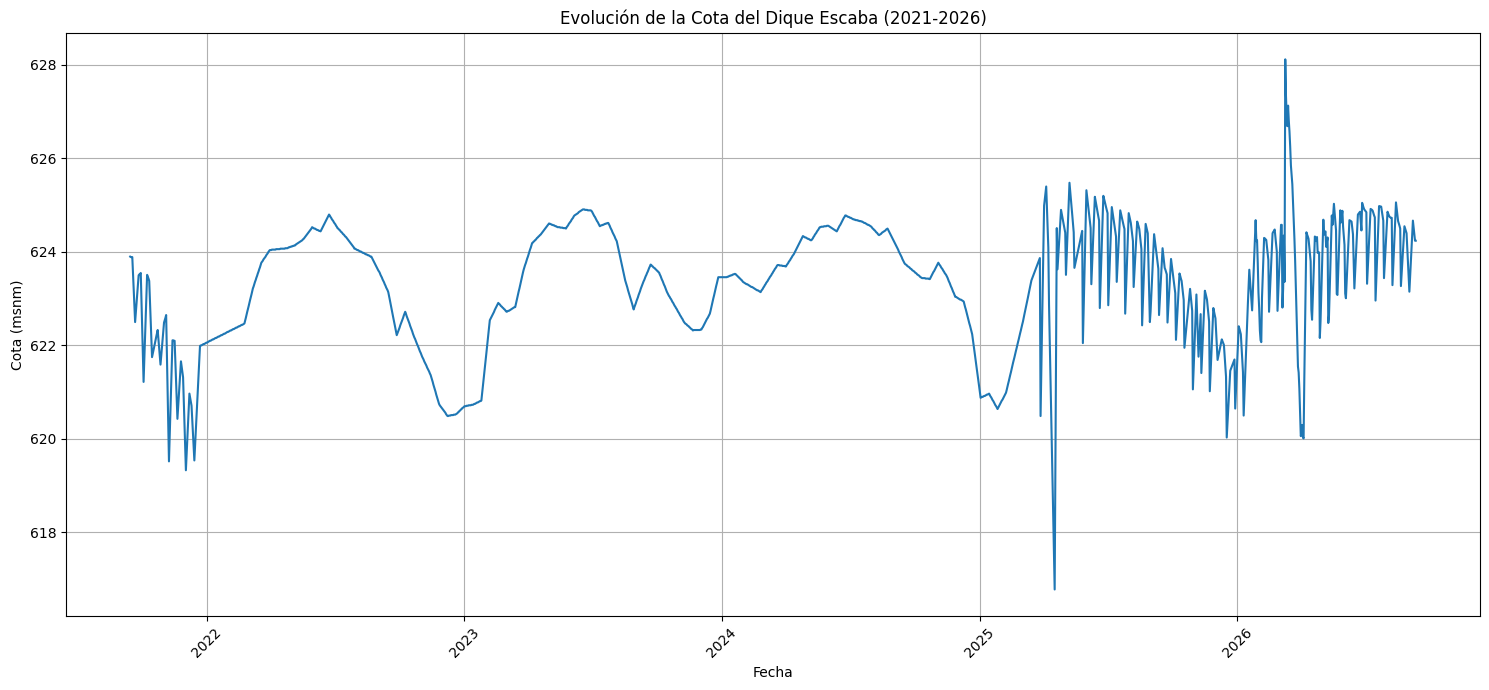

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cargar el historial maestro
df_cota_maestro = pd.read_csv('historial_maestro_escaba_5_anios.csv', sep=';', decimal=',')
df_cota_maestro['Fecha'] = pd.to_datetime(df_cota_maestro['Fecha'])

# Crear la gráfica
plt.figure(figsize=(15, 7))
sns.lineplot(x='Fecha', y='Cota_msnm', data=df_cota_maestro)
plt.title('Evolución de la Cota del Dique Escaba (2021-2026)')
plt.xlabel('Fecha')
plt.ylabel('Cota (msnm)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install flask pyngrok

from flask import Flask, request, jsonify
from pyngrok import ngrok

app = Flask(__name__)

# 1. TU TOKEN DE NGROK
ngrok.set_auth_token("3JNksbHoQgtIJA3fmAujDhD3Ere_if8vQRYPA7Xh1ibiNVxA")

@app.route('/oraculo_colab', methods=['POST'])
def predecir():
    datos = request.json

    lluvia_alta_montana = float(datos.get('lluvia_singuil_mm', 0))
    cota_hoy = float(datos.get('cota_actual', 625.00))

    # --- MATEMÁTICA LÓGICA Y REALISTA ---
    # Una tasa calibrada: 100 mm de lluvia elevan la cota en 1.20 metros.
    aumento_cota = lluvia_alta_montana * 0.012
    cota_proyectada = cota_hoy + aumento_cota

    # --- GATILLO CON LÍMITE FÍSICO ESTRICTO (11 de Marzo) ---
    caudal_erogado = 50.0
    if cota_proyectada >= 627.00:
        caudal_erogado = 310.0 # Tu límite real comprobado
    elif cota_proyectada >= 626.00:
        caudal_erogado = 150.0

    print(f"Lluvia: {lluvia_alta_montana}mm | Cota: {cota_proyectada:.2f} | Erogación: {caudal_erogado}")

    return jsonify({
        "cota_proyectada": round(cota_proyectada, 2),
        "caudal_erogado": round(caudal_erogado, 1)
    })

public_url = ngrok.connect(5000).public_url
print("==========================================================")
print(f"🚀 COPIÁ ESTA URL EN RENDER: {public_url}/oraculo_colab")
print("==========================================================")

app.run(port=5000)

Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
    module = importlib.import_module(module_path)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 

KeyboardInterrupt: 